# Data & Loaders

Overview: explore dataset layout, visualise tiles and permutations.

## Set Up

### General imports

In [1]:
# General imports
import os, sys
from pathlib import Path

# Image processing imports
import torch
from torchvision import transforms

# Notebook-specific imports
import matplotlib.pyplot as plt


### Local imports

In [2]:
cwd = Path.cwd()

if (cwd / "src").exists():
    repo_root = cwd
elif (cwd.parent.parent / "src").exists():
    repo_root = cwd.parent.parent
else:
    raise RuntimeError("Cannot find repo root containing src/")

sys.path.insert(0, str(repo_root.resolve()))

In [3]:
from src.utils import notebook_helpers as nh
from src.utils.permutations import identity_permutation, generate_permutations

## Global Definitions

In [4]:
# Globals
MODE = 'quick'  # 'quick' uses synthetic images; set to 'full' to use real dataset if available
DATA_DIR = os.path.abspath(os.path.join(repo_root, '..', 'data', 'dogs-vs-cats', 'train'))
SAMPLE_COUNT = 8
SEED = 0

## Code

In [5]:
# Helpers (thin wrappers calling src.utils.notebook_helpers)
def show_sample_paths(data_dir=DATA_DIR, n=10):
    return nh.list_sample_paths(data_dir, max_items=n)

def display_tiles_example(use_synthetic=True, grid=2):
    if use_synthetic:
        imgs = nh.create_synthetic_rgb_images(1, size=(224,224), seed=SEED)
        img = imgs[0]
    else:
        samples = show_sample_paths(n=1)
        img = nh.load_pil_image(samples[0][0])
    tiles = nh.split_into_tiles(img, grid)
    fig = nh.visualize_tiles(tiles)
    return fig

## Main
Run a small demo of tiles and permutations.

Quick mode: using synthetic images


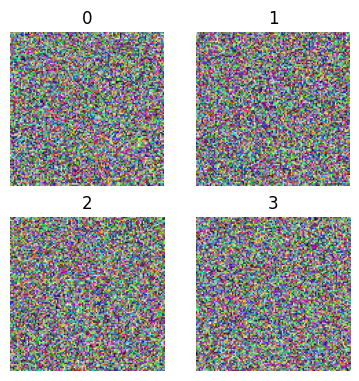

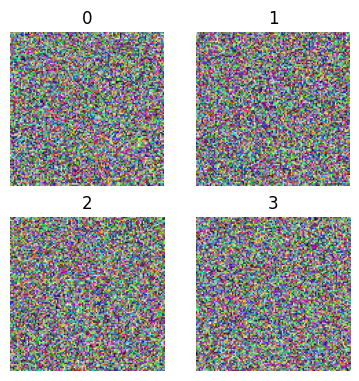

In [6]:
# Show sample paths (if available)
if MODE == 'quick':
    print('Quick mode: using synthetic images')
    fig = display_tiles_example(use_synthetic=True, grid=2)
    display(fig)
else:
    samples = show_sample_paths(n=SAMPLE_COUNT)
    print('Found samples:', len(samples))
    if len(samples):
        fig = display_tiles_example(use_synthetic=False, grid=2)
        display(fig)